# XGBoost -- NO2

Light hyperparameters by default (fast, actually runs). The heavy
grid-search cell below stays commented out -- manual exploration only,
never runs in CI or Airflow.

In [1]:
import matplotlib.pyplot as plt

from src.ml.evaluate import last_fold_predictions, walk_forward_evaluate
from src.ml.models.sklearn_models import XGBoostModel
from src.ml.promote import _variable_config

In [2]:
variable = "NO2"
ano = 2024
air_path = "data/silver/aire/all.parquet"
traffic_path = "data/silver/trafico/all.parquet"
runs_dir = "data/gold/ml_runs"

In [3]:
df, target_col, feature_cols, partition_col = _variable_config(
    variable, air_path, traffic_path
)
df.shape

(15811, 10)

## EDA -- distribution and time series of the target

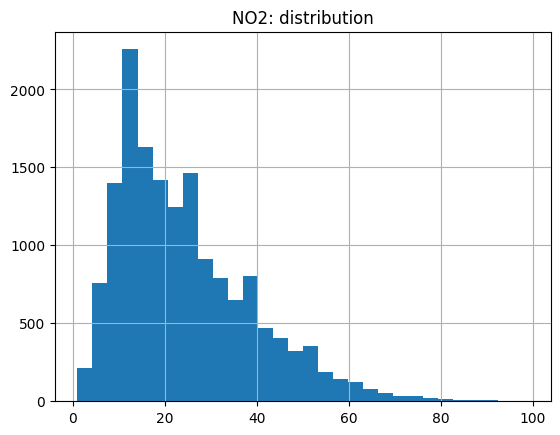

In [4]:
df[target_col].hist(bins=30)
plt.title(f"{variable}: distribution")
plt.show()

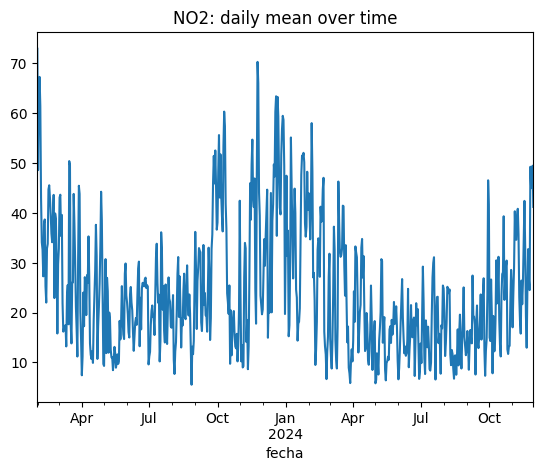

In [5]:
df.groupby("fecha")[target_col].mean().plot()
plt.title(f"{variable}: daily mean over time")
plt.show()

## Light hyperparameters (default, executed)

In [6]:
model = XGBoostModel(n_estimators=50, max_depth=4)

## Heavy grid search -- commented out, uncomment to run (slow)

In [7]:
# from sklearn.model_selection import GridSearchCV
# from xgboost import XGBRegressor
#
# param_grid = {
#     "n_estimators": [50, 150, 300],
#     "max_depth": [3, 4, 6, 8],
#     "learning_rate": [0.3, 0.1, 0.03],
# }
# search = GridSearchCV(
#     XGBRegressor(random_state=42),
#     param_grid,
#     scoring="neg_root_mean_squared_error",
#     cv=3,
#     n_jobs=-1,
# )
# search.fit(df[feature_cols], df[target_col])
# print(search.best_params_, -search.best_score_)

## Walk-forward evaluation + held-out real vs. predicted

In [8]:
comparison = walk_forward_evaluate([model], df, target_col, feature_cols)
comparison

,model,mae,rmse,mape
0,xgboost,7.524361,9.997573,0.422813


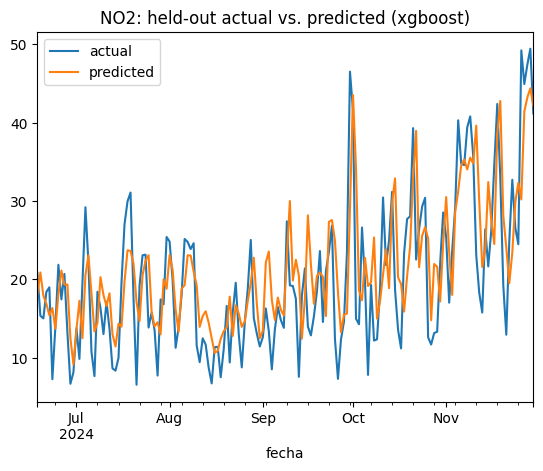

In [9]:
holdout = last_fold_predictions(
    model.__class__(), df, target_col, feature_cols, partition_col
)
holdout.groupby("fecha")[["actual", "predicted"]].mean().plot()
plt.title(f"{variable}: held-out actual vs. predicted ({model.name})")
plt.show()

## Feature importance -- ensembles have one, worth a quick look

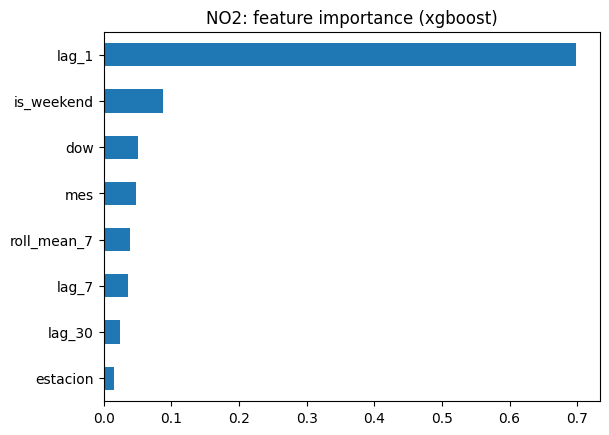

In [10]:
import pandas as pd  # noqa: E402

pd.Series(model._estimator.feature_importances_, index=feature_cols).sort_values().plot(
    kind="barh"
)
plt.title(f"{variable}: feature importance ({model.name})")
plt.show()

## Write this model's run -- never touches `gold/ml_<variable>_<ano>.*`
directly, only `promote.promote_winner` does that.

In [11]:
from pathlib import Path  # noqa: E402

Path(runs_dir).mkdir(parents=True, exist_ok=True)
out = Path(runs_dir) / f"{variable}_{model.name}_{ano}.parquet"
comparison.to_parquet(out)
out

WindowsPath('data/gold/ml_runs/NO2_xgboost_2024.parquet')